In [0]:
# Databricks notebook source
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load cleaned dataset
df_read = pd.read_csv("/Volumes/workspace/default/netflix/netflix_cleaned.csv")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(df_read)



show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_type
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",min
s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",Season
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",Season
s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",Season
s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",Season
s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, Henry Thomas, Kristin Lehman, Samantha Sloyan, Igby Rigney, Rahul Kohli, Annarah Cymone, Annabeth Gish, Alex Essoe, Rahul Abburi, Matt Biedel, Michael Trucco, Crystal Balint, Louis Oliver",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries","The arrival of a charismatic young priest brings glorious miracles, ominous mysteries and renewed religious fervor to a dying town desperate to believe.",Season
s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, Sofia Carson, Liza Koshy, Ken Jeong, Elizabeth Perkins, Jane Krakowski, Michael McKean, Phil LaMarr",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,"Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to heart, she’s determined to prove it.",min
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra Duah, Nick Medley, Mutabaruka, Afemo Omilami, Reggie Carter, Mzuri","United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness to the agony of her ancestral past.",min
s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Hollywood",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV","A talented batch of amateur bakers face off in a 10-week competition, whipping up their best dishes in the hopes of being named the U.K.'s best.",Season
s10,Movie,The Starling,Theodore Melfi

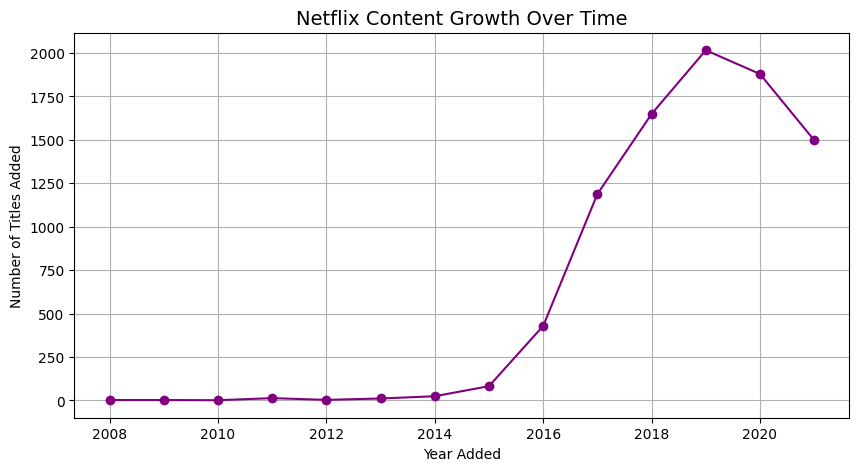

In [0]:

# Netflix Content Growth Over Time

# Convert date_added to datetime
df_read['date_added'] = pd.to_datetime(df_read['date_added'], errors='coerce')

# Extract year from date_added
df_read['year_added'] = df_read['date_added'].dt.year

# Count titles added per year
content_growth = df_read['year_added'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(content_growth.index, content_growth.values, marker='o', color='purple')
plt.title("Netflix Content Growth Over Time", fontsize=14)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.grid(True)
plt.show()


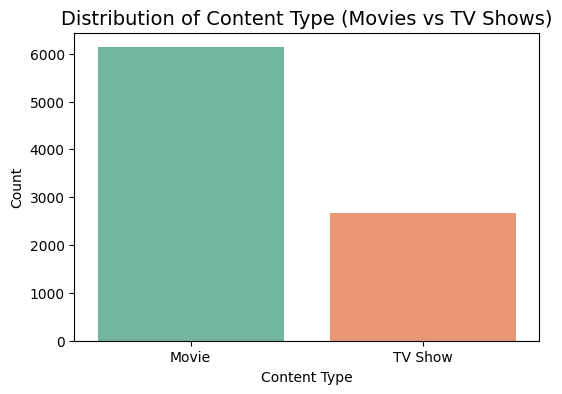

In [0]:
#content type distribution
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df_read, hue='type', palette='Set2', legend=False)
plt.title('Distribution of Content Type (Movies vs TV Shows)', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()


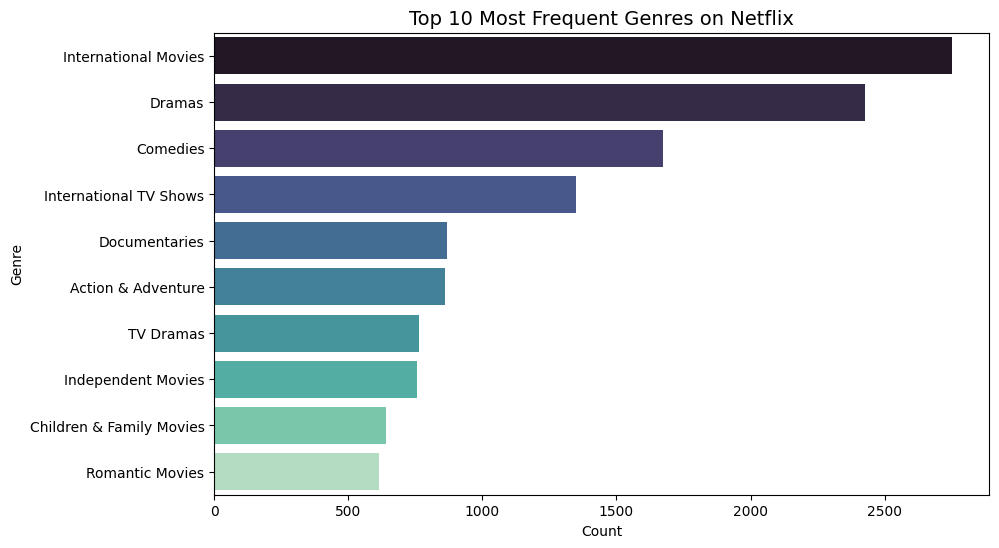

In [0]:
#  top 10 genres using pandas
from collections import Counter

# Split and flatten the 'listed_in' column to get all genres
all_genres = df_read['listed_in'].str.split(',').explode().str.strip()

# Count the occurrences of each genre
top_genres = all_genres.value_counts().head(10).reset_index()
top_genres.columns = ['Genre', 'Count']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    y='Genre',
    x='Count',
    data=top_genres,
    hue='Genre',
    palette='mako',
    legend=False
)
plt.title('Top 10 Most Frequent Genres on Netflix', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

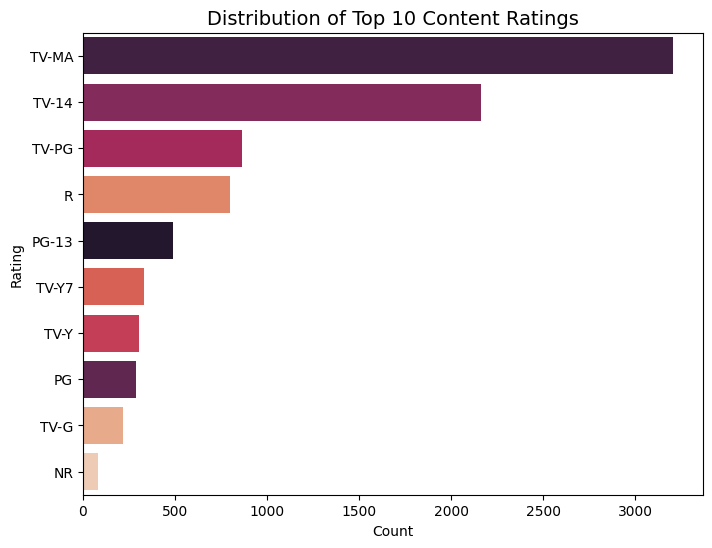

In [0]:
#  top 10 most frequent ratings
top_ratings = df_read['rating'].value_counts().head(10).index
filtered_df = df_read[df_read['rating'].isin(top_ratings)]

plt.figure(figsize=(8,6))
sns.countplot(
    y='rating',
    data=filtered_df,
    order=filtered_df['rating'].value_counts().index,
    palette='rocket',
    hue='rating',
    legend=False
)
plt.title('Distribution of Top 10 Content Ratings', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

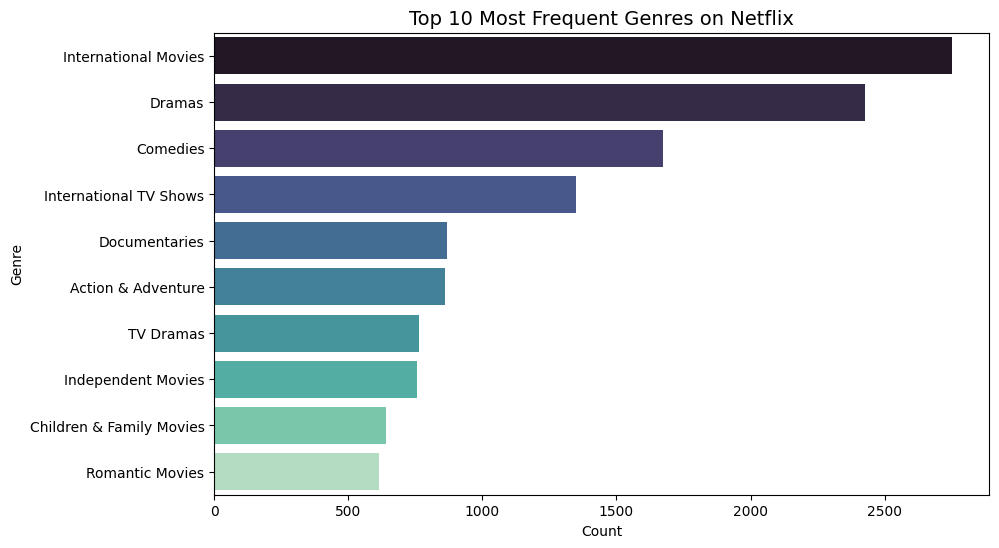

In [0]:
# Calculate top 10 genres using pandas
all_genres = df_read['listed_in'].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(10).reset_index()
top_genres.columns = ['Genre', 'Count']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    y="Genre",
    x="Count",
    data=top_genres,
    hue="Genre",
    palette="mako",
    legend=False
)
plt.title("Top 10 Most Frequent Genres on Netflix", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

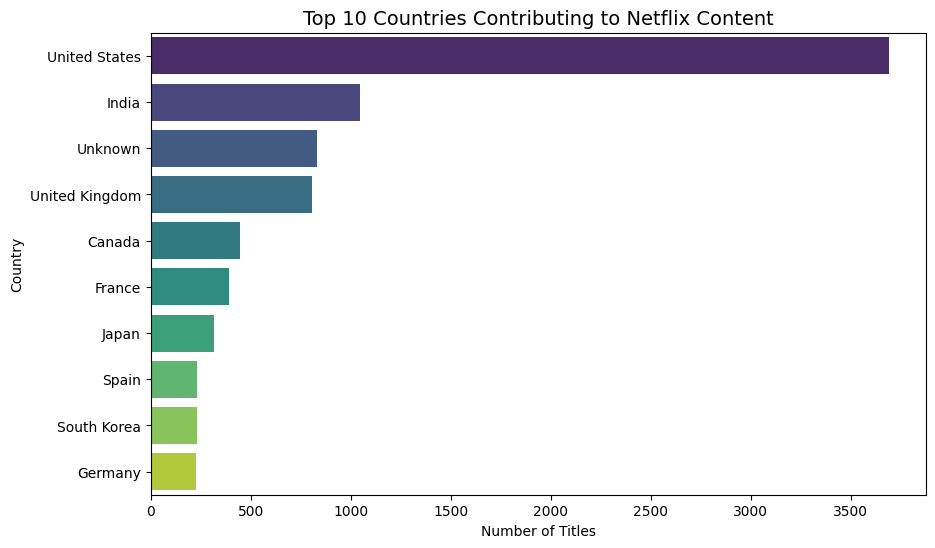

In [0]:
# Calculate top 10 countries contributing Netflix content
all_countries = df_read['country'].dropna().str.split(',').explode().str.strip()
top_countries = all_countries.value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis',
    hue=top_countries.index,
    legend=False
)
plt.title("Top 10 Countries Contributing to Netflix Content", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

title,duration,duration_num,Content_Length_Category
Dick Johnson Is Dead,90 min,90,Medium (1–2hrs)
Blood & Water,2 Seasons,2,Short (<1hr)
Ganglands,1 Season,1,Short (<1hr)
Jailbirds New Orleans,1 Season,1,Short (<1hr)
Kota Factory,2 Seasons,2,Short (<1hr)
Midnight Mass,1 Season,1,Short (<1hr)
My Little Pony: A New Generation,91 min,91,Medium (1–2hrs)
Sankofa,125 min,125,Long (2–3hrs)
The Great British Baking Show,9 Seasons,9,Short (<1hr)
The Starling,104 min,104,Medium (1–2hrs)


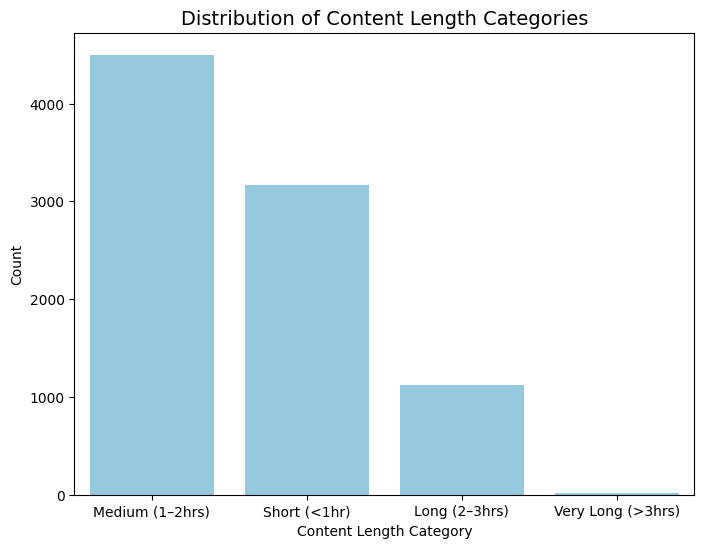

In [0]:

#Content Length
# Extract numeric duration
df_read['duration_num'] = pd.to_numeric(
    df_read['duration'].str.extract(r'(\d+)')[0], errors='coerce'
)

# Function for content length category
def content_length_category(duration):
    if pd.isnull(duration):
        return "Unknown"
    if duration <= 60:
        return "Short (<1hr)"
    elif 60 < duration <= 120:
        return "Medium (1–2hrs)"
    elif 120 < duration <= 200:
        return "Long (2–3hrs)"
    elif duration > 200:
        return "Very Long (>3hrs)"
    else:
        return "Unknown"

df_read['Content_Length_Category'] = df_read['duration_num'].apply(content_length_category)

# Show all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df_read[['title', 'duration', 'duration_num', 'Content_Length_Category']])

# Plot distribution without FutureWarning
plt.figure(figsize=(8,6))
sns.countplot(
    x='Content_Length_Category',
    data=df_read,
    color='skyblue'  # Single color avoids hue warning
)
plt.title("Distribution of Content Length Categories", fontsize=14)
plt.xlabel("Content Length Category")
plt.ylabel("Count")
plt.show()



title,Original_vs_Licensed
Dick Johnson Is Dead,Licensed
Blood & Water,Licensed
Ganglands,Licensed
Jailbirds New Orleans,Licensed
Kota Factory,Licensed
Midnight Mass,Licensed
My Little Pony: A New Generation,Licensed
Sankofa,Licensed
The Great British Baking Show,Licensed
The Starling,Licensed


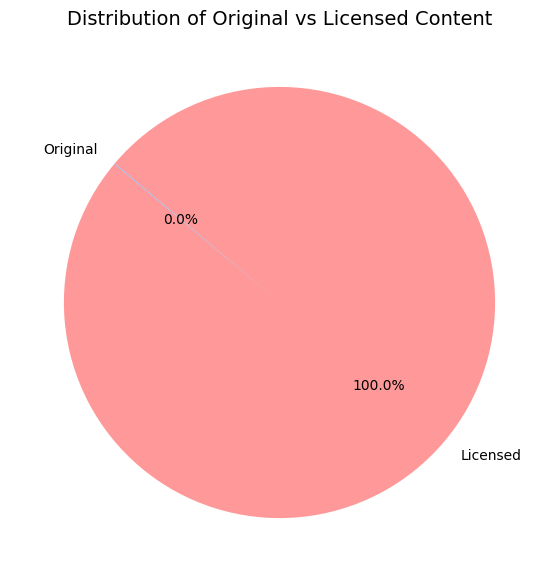

In [0]:
#Feature Engineering - Original vs Licensed
def original_vs_licensed(title):
    if "Netflix" in str(title):
        return "Original"
    else:
        return "Licensed"

df_read['Original_vs_Licensed'] = df_read['title'].apply(original_vs_licensed)

# Show all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_read[['title', 'Original_vs_Licensed']])

# Pie chart for Original vs Licensed
counts = df_read['Original_vs_Licensed'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Original vs Licensed Content', fontsize=14)
plt.show()

In [0]:
# how many originals creted in a a year
originals_per_year = (
    df_read[df_read['Original_vs_Licensed'] == 'Original']
    .groupby('year_added')
    .size()
    .reset_index(name='Originals_Count')
    .sort_values('year_added')
)
display(originals_per_year)

year_added,Originals_Count
2016.0,1
2017.0,1
2020.0,1
2021.0,1


In [0]:
# how many licensed created in a year
licensed_per_year = (
    df_read[df_read['Original_vs_Licensed'] == 'Licensed']
    .groupby('year_added')
    .size()
    .reset_index(name='Licensed_Count')
    .sort_values('year_added')
)
display(licensed_per_year)

year_added,Licensed_Count
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,428
2017.0,1187


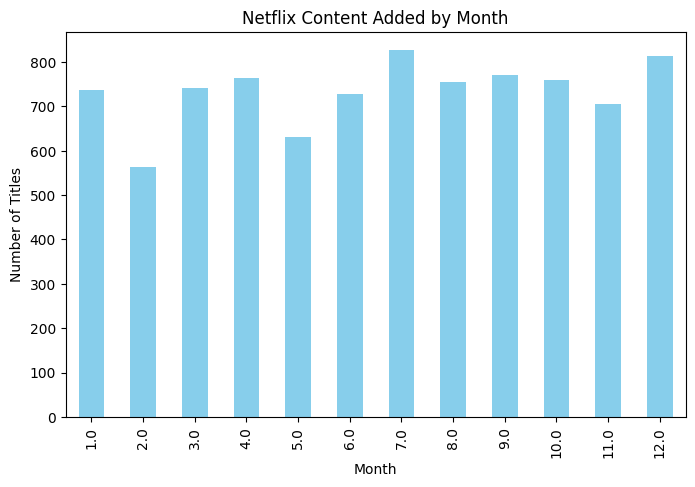

In [0]:
#content growth by month
# Ensure 'date_added' is datetime
df_read['date_added'] = pd.to_datetime(df_read['date_added'], errors='coerce')

# Group by month and plot
monthly_counts = df_read.groupby(df_read['date_added'].dt.month).size()
monthly_counts.plot(
    kind='bar',
    figsize=(8, 5),
    color='skyblue'
)
plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

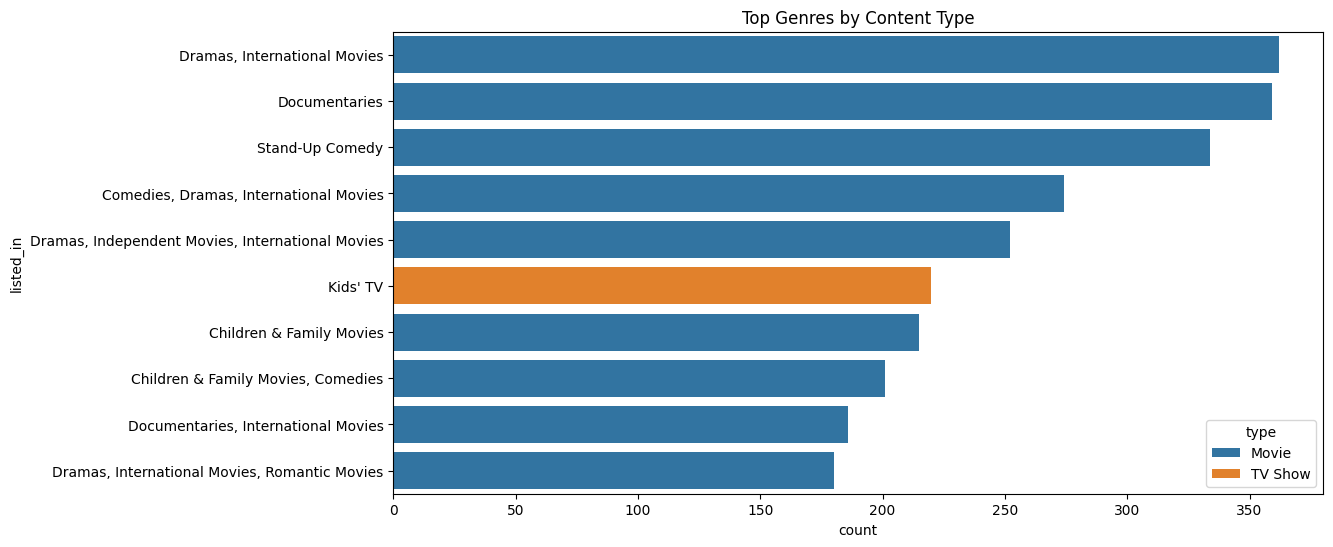

In [0]:
#genre vs content type
plt.figure(figsize=(12,6))
sns.countplot(y='listed_in', hue='type', data=df_read, order=df_read['listed_in'].value_counts().iloc[:10].index)
plt.title("Top Genres by Content Type")
plt.show()


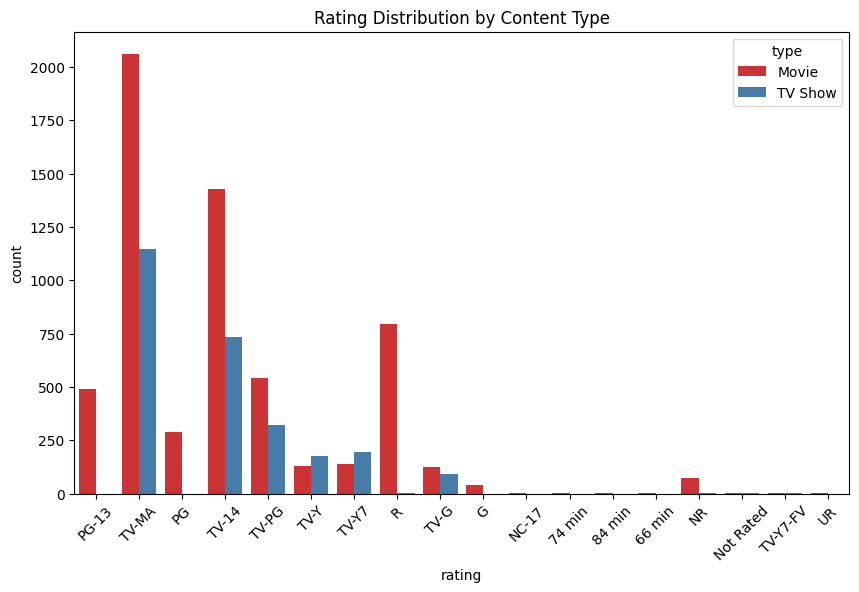

In [0]:
#rating distrubution by content type
plt.figure(figsize=(10,6))
sns.countplot(x='rating', hue='type', data=df_read, palette='Set1')
plt.title("Rating Distribution by Content Type")
plt.xticks(rotation=45)
plt.show()



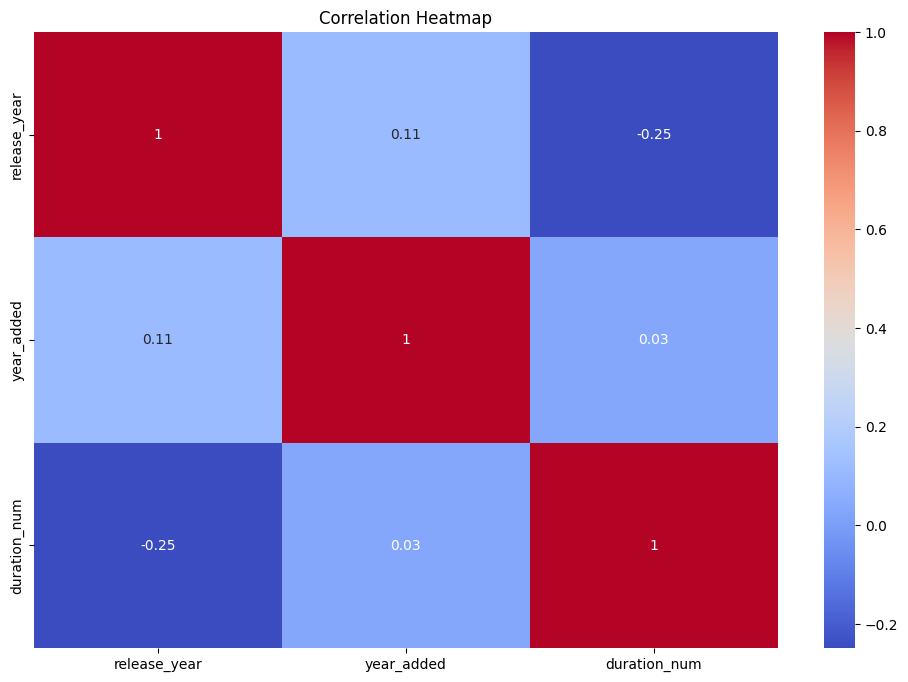

In [0]:
numeric_df = df_read.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [0]:
df_read.to_csv("/Volumes/workspace/default/netflix/netflix_feature_eda.csv", index=False)
print("Feature engineered dataset saved successfully.")


Feature engineered dataset saved successfully.
